In [518]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mtick
import numpy as np
import plotly.express as px
from scipy import stats

In [519]:
# imports risk factor lists
from my_functions import overarching_risks,environmental_and_occupational_risks,behavioural_risks,metabolic_risks,wata,pollu,temp,otherenvir,occupation,childfood,tobacco, childabuse, dietary_risks
from my_functions import assign_grouping, assign_overarching, interval_position, intervals_overlap, summarize_deaths_dalys_full,compute_proportions,format_and_pivot_summary

# Load data
## Dataset nr 1

In [520]:
df=pd.read_excel('./data/Extracted_GBD_data.xlsx')
df.shape, df.groupby('year_gbd').size()

((5184, 8),
 year_gbd
 2010     276
 2013     316
 2015     316
 2016     336
 2017     336
 2019    1710
 2021    1894
 dtype: int64)

## Dataset nr. 2
TOTAL NEEDS TO BE PUT INTO THE FOLDER

In [521]:
#dfs=pd.read_csv('total.csv') 

# Dataset description (Analyzed risk factors)

## Remove rows where risk factors have NA estimates

In [522]:
# Remove NAs
print(df.columns)
print('Number of unique risks in the dataframe -> '+str(len(df.Risk_factor.unique())))

print('Number of na vals (broken down to DALYs and Deaths) \n'+str(df.groupby("measure")["val"].agg(
    missing = lambda x: x.isna().sum(),
    non_missing = lambda x: x.notna().sum()
)
))

df=df[~df['val'].isna()]

print('Number of rows in dataset -> '+str(len(df)))

print('Number of estimates per GBD iteration \n'+str(df.year_gbd.value_counts()))

Index(['Level', 'Risk_factor', 'measure', 'year_gbd', 'anal_year', 'val',
       'lower', 'upper'],
      dtype='object')
Number of unique risks in the dataframe -> 128
Number of na vals (broken down to DALYs and Deaths) 
         missing  non_missing
measure                      
DALYs          9         2619
Deaths        27         2529
Number of rows in dataset -> 5148
Number of estimates per GBD iteration 
year_gbd
2021    1894
2019    1710
2016     332
2017     330
2013     312
2015     312
2010     258
Name: count, dtype: int64


## Harmonizing naming
MINOR DIFFERENCES ALIGNED, OUTLINED IN SUPPLEMENTARY METHODS

In [523]:
# inplace modifications of df
# only place with unimproved are the water sources and sanitation
df['Risk_factor'] = df['Risk_factor'].str.replace('Unimproved', 'Unsafe', regex=False)
df['Risk_factor'] = df['Risk_factor'].str.replace('No handwashing with soap', 'No access to handwashing facility', regex=False)
df.loc[df['Risk_factor'] == 'Occupational exposure to sulfuric acid', 'Risk_factor'] = 'Occupational exposure to sulphuric acid'
df.loc[df['Risk_factor'] == 'Diet low in fibre', 'Risk_factor'] = 'Diet low in fiber'
df.loc[df['Risk_factor'] == 'Diet low in omega 6 polyunsaturated fatty acids', 'Risk_factor'] = 'Diet low in polyunsaturated fatty acids'
df.loc[df['Risk_factor'] == 'Diet low in omega-6 polyunsaturated fatty acids', 'Risk_factor'] = 'Diet low in polyunsaturated fatty acids'
df.loc[df['Risk_factor'] == 'Diet suboptimal in calcium', 'Risk_factor'] = 'Diet low in calcium'
df.loc[df['Risk_factor'] == 'Diet low in polyunsaturated fatty acids', 'Risk_factor'] = 'Diet low in \npolyunsaturated fatty acids'
df.loc[df['Risk_factor'] == 'Diet low in seafood omega 3 fatty acids', 'Risk_factor'] = 'Diet low in \nseafood omega 3 fatty acids'
df.loc[df['Risk_factor'] == 'Diet high in sugar sweetened beverages', 'Risk_factor'] = 'Diet high in \nsugar sweetened beverages'
df.loc[df['Risk_factor'] == 'Physical inactivity and low physical activity', 'Risk_factor'] = 'Low physical activity'
df.loc[df['Risk_factor'] == 'Tobacco smoking', 'Risk_factor'] = 'Smoking'
df.loc[df['Risk_factor'] == 'Tobacco smoking (including second-hand smoke)', 'Risk_factor'] = 'Tobacco'
df.loc[df['Risk_factor'] == 'Tobacco smoke', 'Risk_factor'] = 'Tobacco'
df.loc[df['Risk_factor'] == 'Occupational risk factors for injuries', 'Risk_factor'] = 'Occupational injuries'
df.loc[df['Risk_factor'] == 'Occupational risk factors', 'Risk_factor'] = 'Occupational risks'
df.loc[df['Risk_factor'] == 'Short gestation for birth weight', 'Risk_factor'] = 'Short gestation'
df.loc[df['Risk_factor'] == 'Behavioral risks', 'Risk_factor'] = 'Behavioural risks'
df.loc[df['Risk_factor'] == 'Childhood wasting', 'Risk_factor'] = 'Child wasting'
df.loc[df['Risk_factor'] == 'Childhood stunting', 'Risk_factor'] = 'Child stunting'
df.loc[df['Risk_factor'] == 'High blood pressure', 'Risk_factor'] = 'High systolic blood pressure'
df.loc[df['Risk_factor'] == 'Alcohol use', 'Risk_factor'] = 'High alcohol use'
df.loc[df['Risk_factor'] == 'Physiological risk factors', 'Risk_factor'] = 'Metabolic risks'
df.loc[df['Risk_factor'] == 'Second hand smoke', 'Risk_factor'] = 'Second-hand smoke'
df.loc[df['Risk_factor'] == 'Secondhand smoke', 'Risk_factor'] = 'Second-hand smoke'
df.loc[df['Risk_factor'] == 'Environmental risks', 'Risk_factor'] = 'Environmental/occupational risks'
df.loc[df['Risk_factor'] == 'Environmental or occupational risks', 'Risk_factor'] = 'Environmental/occupational risks'
df.loc[df['Risk_factor'] == 'Unsafe water, sanitation and handwashing', 'Risk_factor'] = 'Unsafe water, sanitation, and handwashing'

# approximate harmonisation
df.loc[df['Risk_factor'] == 'Impaired kidney function', 'Risk_factor'] = 'Kidney dysfunction*'
df.loc[df['Risk_factor'] == 'Low glomerular filtration rate', 'Risk_factor'] = 'Kidney dysfunction*'
df.loc[df['Risk_factor'] == 'Low glomerular filtration rate', 'Risk_factor'] = 'Kidney dysfunction*'
df.loc[df['Risk_factor'] == 'Kidney dysfunction', 'Risk_factor'] = 'Kidney dysfunction*'

df.loc[df['Risk_factor'] == 'High total cholesterol', 'Risk_factor'] = 'High LDL cholesterol*'
df.loc[df['Risk_factor'] == 'High LDL cholesterol', 'Risk_factor'] = 'High LDL cholesterol*'

print('unique risk factors -> '+str(len(df.Risk_factor.unique())))

unique risk factors -> 101


In [524]:
df[(df['Risk_factor']=='Occupational injuries') & (df['measure']=='DALYs')]

,Level,Risk_factor,measure,year_gbd,anal_year,val,lower,upper
202,NaN,Occupational injuries,DALYs,2010,1990,2.126500e+07,1.664400e+07,2.670200e+07
271,NaN,Occupational injuries,DALYs,2010,2010,2.344400e+07,1.773600e+07,3.090400e+07
466,NaN,Occupational injuries,DALYs,2013,1990,9.776000e+06,7.809000e+06,1.288400e+07
545,NaN,Occupational injuries,DALYs,2013,2013,9.947000e+06,7.886000e+06,1.292700e+07
782,NaN,Occupational injuries,DALYs,2015,2005,1.221200e+07,1.073600e+07,1.368200e+07
861,NaN,Occupational injuries,DALYs,2015,2015,1.349200e+07,1.200600e+07,1.554500e+07
1108,3.0,Occupational injuries,DALYs,2016,2006,2.190621e+07,2.035314e+07,2.377695e+07
1192,3.0,Occupational injuries,DALYs,2016,2016,2.177460e+07,1.981066e+07,2.409016e+07
1444,3.0,Occupational injuries,DALYs,2017,2007,2.270000e+07,2.080000e+07,2.480000e+07
1528,3.0,Occupational injuries,DALYs,2017,2017,2.110000e+07,1.920000e+07,2.350000e+07


## 94 estimated across more than one iteration

In [525]:
# Filtering Risk_factors estimated across >1 iteration.
# Find valid Risk_factors (those with >1 unique year_gbd), that is those that more than one GBD iteration has assessed ever.
risk_factors_to_keep = df.groupby('Risk_factor')['year_gbd'].nunique()
risk_factors_to_keep = risk_factors_to_keep[risk_factors_to_keep > 1].index
idx_to_keep = df[df['Risk_factor'].isin(risk_factors_to_keep)].index # get indices to mask
df = df.loc[idx_to_keep] # apply filter to overall dataframe

# Group and get (Risk_factor, anal_year) pairs with >1 year_gbd, i.e. this gives you the risk-year combinations that have more than one gbd estimate
rf_ay_multiindex = df.groupby(['Risk_factor', 'anal_year'])['year_gbd'].nunique()
rf_ay_multiindex = rf_ay_multiindex[rf_ay_multiindex > 1].index  # MultiIndex
mask_consistency = df.set_index(['Risk_factor', 'anal_year']).index.isin(rf_ay_multiindex) # get index
idx_consistency = df.index[mask_consistency] # apply index
df_conscheck = df.loc[idx_consistency] # apply filter to df_conscheck

df_comp=df[df['anal_year']==df['year_gbd']]

df_comp.to_csv('./data/processed_data/df_comp.csv', index=False)
df.to_csv('./data/processed_data/df.csv', index=False)

print('Overall dataframe after filter is unchanged see 5113 earlier -> '+str(len(df)))
print('Dataframe to compare the GBD iterations same year estimates (same as iteration) -> '+str(len(df_comp)))
print('Number of unique risk factors for same year estimates (same as iteration) df -> '+str(len(df_comp.Risk_factor.unique())))
print('Dataframe to compare the matched risk-year pairs -> '+str(len(df_conscheck)))
print('Number of unique risk factors for matched risk-year pairs df -> '+str(len(df_conscheck.Risk_factor.unique())))


Overall dataframe after filter is unchanged see 5113 earlier -> 5113
Dataframe to compare the GBD iterations same year estimates (same as iteration) -> 1107
Number of unique risk factors for same year estimates (same as iteration) df -> 94
Dataframe to compare the matched risk-year pairs -> 4862
Number of unique risk factors for matched risk-year pairs df -> 90


# Define the categories of risk factors

In [526]:
# Add the overarching risks afterwards (to not plot them twice)
environmental_and_occupational_risks1=['Environmental/occupational risks']+environmental_and_occupational_risks

behavioural_risks1=['Behavioural risks']+behavioural_risks

metabolic_risks1=['Metabolic risks']+metabolic_risks

In [527]:
df[df['Risk_factor'].isin(childabuse)]['Risk_factor'].unique()

array(['Sexual abuse and violence', 'Childhood sexual abuse',
       'Bullying victimization', 'Sexual violence against children',
       'Sexual violence against children and bullying'], dtype=object)

#### level 4 risks removed, abuse related estimates delegated to the supplement.

In [528]:
overarching_risks

['Environmental/occupational risks',
 'Behavioural risks',
 'Metabolic risks',
 'All risk factors']

## Create the two datasets
temps and temps_comp first for the matched risk-year analysis and the second for the across iteration and year comparison (GBD 2010 informs 2010, GBD 2013 informs 2013 etc.) that only contain **level 1-3 estimates**

DOCUMENTATION CAVEATS! FIX THAT SHIT (ERROR)

In [529]:
# filter to get all the level 3 and level 2 risks and classify them accordingly for the next steps
filt_rel = (
    overarching_risks + environmental_and_occupational_risks + behavioural_risks +
    metabolic_risks + wata + pollu + temp + otherenvir + occupation + childfood +
    tobacco + dietary_risks
)

# Make explicit copies after filtering
temps = df[df['Risk_factor'].isin(filt_rel)].copy()
temps_comp = df_comp[df_comp['Risk_factor'].isin(filt_rel)].copy()

# --- Apply Group and Overarching_group assignments ---
temps['Group'] = temps['Risk_factor'].apply(assign_grouping)
temps['Overarching_group'] = temps['Group'].apply(assign_overarching)
temps.loc[temps['Overarching_group'] == 'Other', 'Overarching_group'] = temps.loc[
    temps['Overarching_group'] == 'Other', 'Risk_factor'
]

temps_comp['Group'] = temps_comp['Risk_factor'].apply(assign_grouping)
temps_comp['Overarching_group'] = temps_comp['Group'].apply(assign_overarching)
temps_comp.loc[temps_comp['Overarching_group'] == 'Other', 'Overarching_group'] = temps_comp.loc[
    temps_comp['Overarching_group'] == 'Other', 'Risk_factor'
]

# Save outputs
temps_comp.to_csv('./data/processed_data/temps_comp.csv', index=False)
temps.to_csv('./data/processed_data/temps.csv', index=False)

# Print counts
print('Number of estimates in the dataframe with down to level 3 and no level 4 ->', len(temps))
print('Number of unique risks in the dataframe with down to level 3 and no level 4 ->', temps['Risk_factor'].nunique())
print('\nNumber of estimates in the dataframe with down to level 3 and no level 4, same year as GBD iteration comp ->', len(temps_comp))
print('Number of unique risks in the dataframe with down to level 3 and no level 4, same year as GBD iteration comp ->', temps_comp['Risk_factor'].nunique())

Number of estimates in the dataframe with down to level 3 and no level 4 -> 3738
Number of unique risks in the dataframe with down to level 3 and no level 4 -> 65

Number of estimates in the dataframe with down to level 3 and no level 4, same year as GBD iteration comp -> 800
Number of unique risks in the dataframe with down to level 3 and no level 4, same year as GBD iteration comp -> 65


## Further filtering, no level 4 and others removed and the remaining
The set below contains 23 Level 4 estimates that were removed and Alcohol and drug use (Level 2)

In [530]:
print('Number of childabuse risks removed: ', (df[df['Risk_factor'].isin(childabuse)]['Risk_factor'].nunique()))
((set(df[~df['Risk_factor'].isin(filt_rel)]['Risk_factor'].unique())))

Number of childabuse risks removed:  5


{'Alcohol and drug use',
 'Bullying victimization',
 'Child stunting',
 'Child underweight',
 'Child wasting',
 'Childhood sexual abuse',
 'Childhood underweight',
 'Discontinued breastfeeding',
 'Low birth weight',
 'Low birth weight for gestation',
 'Non-exclusive breastfeeding',
 'Occupational exposure to arsenic',
 'Occupational exposure to asbestos',
 'Occupational exposure to benzene',
 'Occupational exposure to beryllium',
 'Occupational exposure to cadmium',
 'Occupational exposure to chromium',
 'Occupational exposure to diesel engine exhaust',
 'Occupational exposure to formaldehyde',
 'Occupational exposure to nickel',
 'Occupational exposure to polycyclic aromatic hydrocarbons',
 'Occupational exposure to second-hand smoke',
 'Occupational exposure to silica',
 'Occupational exposure to sulphuric acid',
 'Occupational exposure to trichloroethylene',
 'Sexual abuse and violence',
 'Sexual violence against children',
 'Sexual violence against children and bullying',
 'Short g

Dont forget this adds to 64 and then we have Level 0 (All risk factors)

In [531]:
print('Number of Level 1 risks: '+str(temps.Overarching_group.nunique()-1)) # remove one for All risk factors
print('Number of Level 2 risks: '+str(temps[temps['Group']!='Other']['Group'].nunique()))
print('Number of Level 3 risks: ' + str(temps[(temps['Risk_factor']!=temps['Group'])&(temps['Risk_factor']!=temps['Overarching_group']) & (temps['Risk_factor']!='All risk factors')]['Risk_factor'].nunique()))

Number of Level 1 risks: 3
Number of Level 2 risks: 19
Number of Level 3 risks: 42


# Manual validation sample of extraction

In [532]:
# Example: assuming your DataFrame is called df
temps[temps['year_gbd'].isin([2010,2013,2015,2016,2017])].sample(n=100, random_state=1453).to_csv('random_validation_sample_100.csv')

## eTable 1

In [ ]:
temps.groupby(['Overarching_group', 'Group'])['Risk_factor'].unique().reset_index().to_csv('./tables/eTable 1.csv')

## Table 1: Median and range of estimates for deaths and DALYs
### for the timeline 2017-2021 and then 2010-2021

In [534]:
summary_wide_cons, summary_wide = summarize_deaths_dalys_full(temps_comp, min_year=2016)

In [535]:
summary_wide[['rmu_Deaths','rmu_DALYs','cv_Deaths','cv_DALYs']]

,rmu_Deaths,rmu_DALYs,cv_Deaths,cv_DALYs
0,0.026556,0.015841,0.015221,0.008474
1,0.212761,0.184478,0.106970,0.092695
2,0.288078,0.294956,0.144729,0.148562
3,0.564433,0.098203,0.288692,0.051080
4,0.143384,0.105702,0.073701,0.052970
...,...,...,...,...
59,0.330530,0.333838,0.165579,0.168242
60,0.325005,0.475179,0.174294,0.262342
61,0.052768,0.116924,0.030439,0.060847
62,NaN,0.037793,NaN,0.018944


In [536]:
summary_wide.rmu_DALYs.min()

0.01584115848088283

In [537]:
summary_wide.columns

Index(['Overarching_group', 'Group', 'Risk_factor', 'median_Deaths',
       'min_Deaths', 'max_Deaths', 'n_estimates_Deaths', 'mean_Deaths',
       'std_Deaths', 'mad_Deaths', 'range_Deaths',
       'fold_range_vs_median_Deaths', 'rmu_Deaths', 'cv_Deaths',
       'max_vs_min_Deaths', 'f_med_Deaths', 'rcv_m_Deaths', 'median_DALYs',
       'min_DALYs', 'max_DALYs', 'n_estimates_DALYs', 'mean_DALYs',
       'std_DALYs', 'mad_DALYs', 'range_DALYs', 'fold_range_vs_median_DALYs',
       'rmu_DALYs', 'cv_DALYs', 'max_vs_min_DALYs', 'f_med_DALYs',
       'rcv_m_DALYs'],
      dtype='object')

In [538]:
print('Median range/mean deaths risks 2017-2021: '+str(summary_wide.rmu_Deaths.median())+' ('+str(summary_wide.rmu_Deaths.min())+'-'+str(summary_wide.rmu_Deaths.max())+')',
    '\nMedian range/mean daly risks 2017-2021: '+str(summary_wide.rmu_DALYs.median())+' ('+str(summary_wide.rmu_DALYs.min())+'-'+str(summary_wide.rmu_DALYs.max())+')')

Median range/mean deaths risks 2017-2021: 0.3698932188445182 (0.025535105961651306-2.458750504662149) 
Median range/mean daly risks 2017-2021: 0.32861967752084054 (0.01584115848088283-2.441923213214949)


In [539]:
print('Median cv deaths risks 2017-2021: '+str(summary_wide.cv_Deaths.median())+' ('+str(summary_wide.cv_Deaths.min())+'-'+str(summary_wide.cv_Deaths.max())+')',
    '\nMedian cv daly risks 2017-2021: '+str(summary_wide.cv_DALYs.median())+' ('+str(summary_wide.cv_DALYs.min())+'-'+str(summary_wide.cv_DALYs.max())+')')

Median cv deaths risks 2017-2021: 0.2135028159517799 (0.015221301457097984-1.3896432133912229) 
Median cv daly risks 2017-2021: 0.170021429773235 (0.008473667981791538-1.3789633147364393)


In [540]:
# Calculate proportions for Deaths
proportion_deaths_above_1 = (summary_wide['rmu_Deaths'] > 1).mean()

# Calculate proportions for DALYs
proportion_dalys_above_1 = (summary_wide['rmu_DALYs'] > 1).mean()

print(f"Proportion of rmu_Deaths above 1: {proportion_deaths_above_1:.2%}")
print(f"Proportion of rmu_DALYs above 1: {proportion_dalys_above_1:.2%}")

Proportion of rmu_Deaths above 1: 12.50%
Proportion of rmu_DALYs above 1: 10.94%


In [541]:
sorted_df = compute_proportions(summary_wide)
sorted_df

,Overarching_group,Group,DALYs,Deaths
0,All risk factors,NaN,0/1 (0.0),0/1 (0.0)
0,All risk factors,Other,0/1 (0.0),0/1 (0.0)
1,Behavioural risks,NaN,7/33 (0.21),8/33 (0.24)
1,Behavioural risks,Child and maternal malnutrition,2/7 (0.29),2/7 (0.29)
2,Behavioural risks,Dietary risks,5/16 (0.31),6/16 (0.38)
3,Behavioural risks,Drug use,0/1 (0.0),0/1 (0.0)
4,Behavioural risks,High alcohol use,0/1 (0.0),0/1 (0.0)
5,Behavioural risks,Intimate partner violence,0/1 (0.0),0/1 (0.0)
6,Behavioural risks,Low physical activity,0/1 (0.0),0/1 (0.0)
7,Behavioural risks,Other,0/1 (0.0),0/1 (0.0)


In [542]:
summary_wide_cons, summary_wide = summarize_deaths_dalys_full(temps_comp[temps_comp['year_gbd'].isin([2015,2016,2017])])

In [543]:
sorted_df = compute_proportions(summary_wide)
sorted_df

,Overarching_group,Group,DALYs,Deaths
0,All risk factors,NaN,0/1 (0.0),0/1 (0.0)
0,All risk factors,Other,0/1 (0.0),0/1 (0.0)
1,Behavioural risks,NaN,3/34 (0.09),6/34 (0.18)
1,Behavioural risks,Child and maternal malnutrition,1/8 (0.12),3/8 (0.38)
2,Behavioural risks,Dietary risks,2/16 (0.12),2/16 (0.12)
3,Behavioural risks,Drug use,0/1 (0.0),0/1 (0.0)
4,Behavioural risks,High alcohol use,0/1 (0.0),0/1 (0.0)
5,Behavioural risks,Intimate partner violence,0/1 (0.0),1/1 (1.0)
6,Behavioural risks,Low physical activity,0/1 (0.0),0/1 (0.0)
7,Behavioural risks,Other,0/1 (0.0),0/1 (0.0)


In [544]:
summary_wide_cons, summary_wide = summarize_deaths_dalys_full(temps_comp)

In [545]:
print('Median range/mean deaths risks 1990-2021: '+str(summary_wide.rmu_Deaths.median())+' ('+str(summary_wide.rmu_Deaths.min())+'-'+str(summary_wide.rmu_Deaths.max())+')',
    '\nMedian range/mean daly risks 1990-2021: '+str(summary_wide.rmu_DALYs.median())+' ('+str(summary_wide.rmu_DALYs.min())+'-'+str(summary_wide.rmu_DALYs.max())+')')

Median range/mean deaths risks 1990-2021: 0.7127747395214445 (0.025535105961651306-4.147428210003686) 
Median range/mean daly risks 1990-2021: 0.6122287533536708 (0.02836490676942493-3.613743328791362)


In [546]:
print('Median CV deaths risks 1990-2021: '+str(summary_wide.cv_Deaths.median())+' ('+str(summary_wide.cv_Deaths.min())+'-'+str(summary_wide.cv_Deaths.max())+')',
    '\nMedian CV daly risks 1990-2021: '+str(summary_wide.cv_DALYs.median())+' ('+str(summary_wide.cv_DALYs.min())+'-'+str(summary_wide.cv_DALYs.max())+')')

Median CV deaths risks 1990-2021: 0.2603133124875996 (0.018056046583800677-1.5319200847729761) 
Median CV daly risks 1990-2021: 0.22674591392853652 (0.020057017924384576-1.3290515440190815)


In [547]:
summary_wide[['rmu_Deaths', 'f_med_Deaths', 'cv_Deaths']].corr(method='spearman')

,rmu_Deaths,f_med_Deaths,cv_Deaths
rmu_Deaths,1.000000,0.942924,0.980943
f_med_Deaths,0.942924,1.000000,0.930108
cv_Deaths,0.980943,0.930108,1.000000


In [548]:
# Calculate medians for each group, skipping NaN values
behavioural_risks_median = summary_wide[summary_wide['Overarching_group'] == 'Behavioural risks'].rmu_Deaths.median(skipna=True)
environmental_risks_median = summary_wide[summary_wide['Overarching_group'] == 'Environmental/occupational risks'].rmu_Deaths.median(skipna=True)
metabolic_risks_median = summary_wide[summary_wide['Overarching_group'] == 'Metabolic risks'].rmu_Deaths.median(skipna=True)

# Print the results
print(f"Behavioural risks median R/M: {behavioural_risks_median}")
print(f"Environmental/occupational risks median R/M: {environmental_risks_median}")
print(f"Metabolic risks median R/M: {metabolic_risks_median}")

# Calculate medians for each group, skipping NaN values
behavioural_risks_median = summary_wide[summary_wide['Overarching_group'] == 'Behavioural risks'].rmu_DALYs.median(skipna=True)
environmental_risks_median = summary_wide[summary_wide['Overarching_group'] == 'Environmental/occupational risks'].rmu_DALYs.median(skipna=True)
metabolic_risks_median = summary_wide[summary_wide['Overarching_group'] == 'Metabolic risks'].rmu_DALYs.median(skipna=True)

# Print the results
print(f"Behavioural risks median R/M: {behavioural_risks_median}")
print(f"Environmental/occupational risks median R/M: {environmental_risks_median}")
print(f"Metabolic risks median R/M: {metabolic_risks_median}")

Behavioural risks median R/M: 0.9125866380551038
Environmental/occupational risks median R/M: 0.6821440720982241
Metabolic risks median R/M: 0.5298898941674416
Behavioural risks median R/M: 0.7714226075816208
Environmental/occupational risks median R/M: 0.5213432301934434
Metabolic risks median R/M: 0.5269052665766861


In [549]:
# Sort by 'Overarching_group' first
sorted_summary = summary_wide.sort_values(by='Overarching_group')

# Group by 'Group' and calculate the median for the specified columns
group_medians = sorted_summary.groupby('Group')[['rmu_Deaths', 'rmu_DALYs']].median()

# Display the result
group_medians

,rmu_Deaths,rmu_DALYs
Group,,
Air pollution,0.517255,0.531054
Child and maternal malnutrition,1.141480,0.575164
Dietary risks,1.051480,1.004554
Drug use,0.973909,0.589738
High LDL cholesterol*,0.642320,0.712078
High alcohol use,0.406795,0.644732
High body-mass index,0.387811,0.507192
High fasting plasma glucose,0.607879,0.586192
High systolic blood pressure,0.139607,0.291722


In [550]:
df = summary_wide.copy()

# --- 1. Compute where the median lies as % of the range --- DALYs
df['median_position_pct_DALYs'] = (
    100 * (df['median_DALYs'] - df['min_DALYs']) /
    (df['max_DALYs'] - df['min_DALYs'])
)

# --- 1. Compute where the median lies as % of the range --- Deaths

df['median_position_pct_Deaths'] = (
    100 * (df['median_Deaths'] - df['min_Deaths']) /
    (df['max_Deaths'] - df['min_Deaths'])
)

df['median_bin_DALYs'] = pd.cut(df['median_position_pct_DALYs'], bins=np.arange(0, 101, 20))
df['median_bin_Deaths'] = pd.cut(df['median_position_pct_Deaths'], bins=np.arange(0, 101, 20))

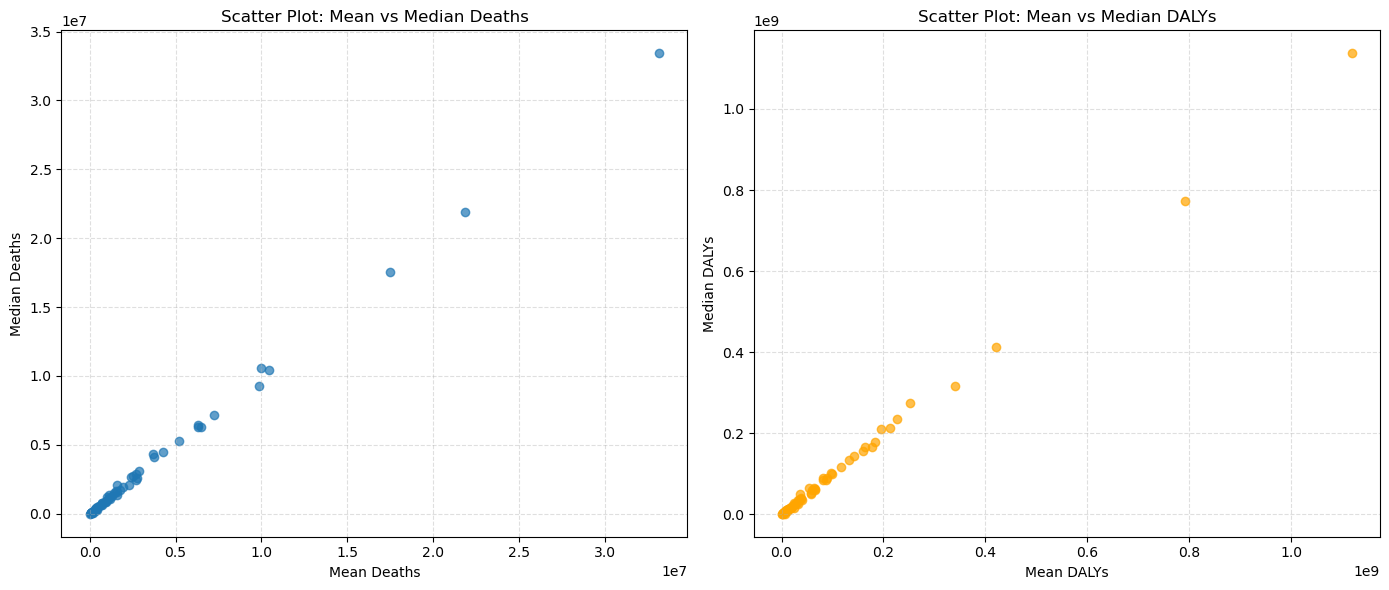

In [551]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for Deaths
axes[0].scatter(df['mean_Deaths'], df['median_Deaths'], alpha=0.7)
axes[0].set_xlabel('Mean Deaths')
axes[0].set_ylabel('Median Deaths')
axes[0].set_title('Scatter Plot: Mean vs Median Deaths')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Scatter plot for DALYs
axes[1].scatter(df['mean_DALYs'], df['median_DALYs'], alpha=0.7, color='orange')
axes[1].set_xlabel('Mean DALYs')
axes[1].set_ylabel('Median DALYs')
axes[1].set_title('Scatter Plot: Mean vs Median DALYs')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
summary_wide=summary_wide.round(1)
summary_wide['Median Deaths (Min-Max)']=summary_wide['median_Deaths'].astype(str) + ' ('+ summary_wide['min_Deaths'].astype(str)+'-'+summary_wide['max_Deaths'].astype(str)+')'
summary_wide['Median DALYs (Min-Max)']=summary_wide['median_DALYs'].astype(str) + ' ('+ summary_wide['min_DALYs'].astype(str)+'-'+summary_wide['max_DALYs'].astype(str)+')'
summary_wide.to_csv('./tables/Supplementary Data File 1.csv')

# Fix the Table 2
table1=pd.concat([summary_wide[summary_wide['rmu_Deaths']>1.5],summary_wide[summary_wide['rmu_DALYs']>1.5]])
table1[['Overarching_group','Group','Risk_factor','Median Deaths (Min-Max)','rmu_Deaths','Median DALYs (Min-Max)','rmu_DALYs','n_estimates_Deaths','n_estimates_DALYs', 'cv_Deaths','cv_DALYs']].to_csv('./tables/Table 1.csv')

In [ ]:
table1

,Overarching_group,Group,Risk_factor,median_Deaths,min_Deaths,max_Deaths,n_estimates_Deaths,mean_Deaths,std_Deaths,mad_Deaths,...,mad_DALYs,range_DALYs,fold_range_vs_median_DALYs,rmu_DALYs,cv_DALYs,max_vs_min_DALYs,f_med_DALYs,rcv_m_DALYs,Median Deaths (Min-Max),Median DALYs (Min-Max)
4,Behavioural risks,Child and maternal malnutrition,Iron deficiency,60000.0,20950.0,199000.0,7.0,80028.4,62101.4,25708.2,...,4586744.9,21606874.9,0.6,0.5,0.2,1.7,1.5,0.2,60000.0 (20950.0-199000.0),35849870.0 (31263125.1-52870000.0)
7,Behavioural risks,Child and maternal malnutrition,Vitamin A deficiency,83000.0,17374.4,233000.0,7.0,86309.5,74442.9,40820.0,...,3631950.0,26336244.3,3.5,2.8,1.0,10.9,3.8,0.7,83000.0 (17374.4-233000.0),7611000.0 (2663755.7-29000000.0)
8,Behavioural risks,Child and maternal malnutrition,Zinc deficiency,29000.0,1611.6,97330.0,7.0,39548.2,35087.2,26194.1,...,2387000.0,8987553.0,3.5,2.5,0.9,61.5,17.4,1.4,29000.0 (1611.6-97330.0),2580000.0 (148447.0-9136000.0)
9,Behavioural risks,Dietary risks,Diet high in \nsugar sweetened beverages,126000.0,22560.0,299521.0,7.0,134574.9,103294.8,87000.0,...,1857561.8,7773490.0,1.7,1.7,0.6,11.0,5.7,0.6,126000.0 (22560.0-299521.0),4450000.0 (779510.0-8553000.0)
10,Behavioural risks,Dietary risks,Diet high in processed meat,304284.4,130000.0,840857.0,7.0,413575.7,268734.6,174284.4,...,6787091.0,17742960.0,1.7,1.6,0.6,6.6,3.2,1.0,304284.4 (130000.0-840857.0),10357091.0 (3196040.0-20939000.0)
11,Behavioural risks,Dietary risks,Diet high in red meat,43000.0,25000.0,895674.9,7.0,209931.3,321597.9,18000.0,...,605670.0,22613743.8,12.2,3.6,1.3,19.1,12.9,0.5,43000.0 (25000.0-895674.9),1853000.0 (1247330.0-23861073.8)
28,Behavioural risks,Low physical activity,Low physical activity,1373340.0,657618.7,3183940.0,7.0,1584771.5,865220.4,541838.0,...,8610899.6,53613039.6,2.2,1.6,0.6,4.4,2.9,0.5,1373340.0 (657618.7-3183940.0),24315860.0 (15704960.4-69318000.0)
44,Environmental/occupational risks,Occupational risks,Occupational carcinogens,341997.8,118097.0,746540.0,7.0,383422.9,193632.2,37997.8,...,1654983.1,18001730.0,2.4,2.1,0.7,7.7,2.8,0.3,341997.8 (118097.0-746540.0),7457983.1 (2681000.0-20682730.0)
7,Behavioural risks,Child and maternal malnutrition,Vitamin A deficiency,83000.0,17374.4,233000.0,7.0,86309.5,74442.9,40820.0,...,3631950.0,26336244.3,3.5,2.8,1.0,10.9,3.8,0.7,83000.0 (17374.4-233000.0),7611000.0 (2663755.7-29000000.0)
8,Behavioural risks,Child and maternal malnutrition,Zinc deficiency,29000.0,1611.6,97330.0,7.0,39548.2,35087.2,26194.1,...,2387000.0,8987553.0,3.5,2.5,0.9,61.5,17.4,1.4,29000.0 (1611.6-97330.0),2580000.0 (148447.0-9136000.0)


In [ ]:
# Using your wide summary
sorted_df = compute_proportions(summary_wide, output_csv='./tables/eTable 2.csv')
sorted_df

,Overarching_group,Group,DALYs,Deaths
0,All risk factors,NaN,0/1 (0.0),0/1 (0.0)
0,All risk factors,Other,0/1 (0.0),0/1 (0.0)
1,Behavioural risks,NaN,11/34 (0.32),14/34 (0.41)
1,Behavioural risks,Child and maternal malnutrition,3/8 (0.38),4/8 (0.5)
2,Behavioural risks,Dietary risks,6/16 (0.38),8/16 (0.5)
3,Behavioural risks,Drug use,0/1 (0.0),0/1 (0.0)
4,Behavioural risks,High alcohol use,0/1 (0.0),0/1 (0.0)
5,Behavioural risks,Intimate partner violence,1/1 (1.0),1/1 (1.0)
6,Behavioural risks,Low physical activity,1/1 (1.0),1/1 (1.0)
7,Behavioural risks,Other,0/1 (0.0),0/1 (0.0)


### Same thing as before but for Matched risk-year pairs 

In [555]:
temps=temps[temps['anal_year']<=2019]
temps.shape

(3612, 10)

In [556]:
summary_wide_cons, summary_wide = summarize_deaths_dalys_full(temps,exclude_group='Other')
# here summary_wide is pointless to use.
summary_wide_cons.to_csv('./tables/Supplementary Data File 2.csv')

In [557]:
df = summary_wide_cons.copy()

# --- 1. Compute where the median lies as % of the range --- DALYs
df['median_position_pct_DALYs'] = (
    100 * (df['median_DALYs'] - df['min_DALYs']) /
    (df['max_DALYs'] - df['min_DALYs'])
)

# --- 1. Compute where the median lies as % of the range --- Deaths

df['median_position_pct_Deaths'] = (
    100 * (df['median_Deaths'] - df['min_Deaths']) /
    (df['max_Deaths'] - df['min_Deaths'])
)

df['median_bin_DALYs'] = pd.cut(df['median_position_pct_DALYs'], bins=np.arange(0, 101, 20))
df['median_bin_Deaths'] = pd.cut(df['median_position_pct_Deaths'], bins=np.arange(0, 101, 20))

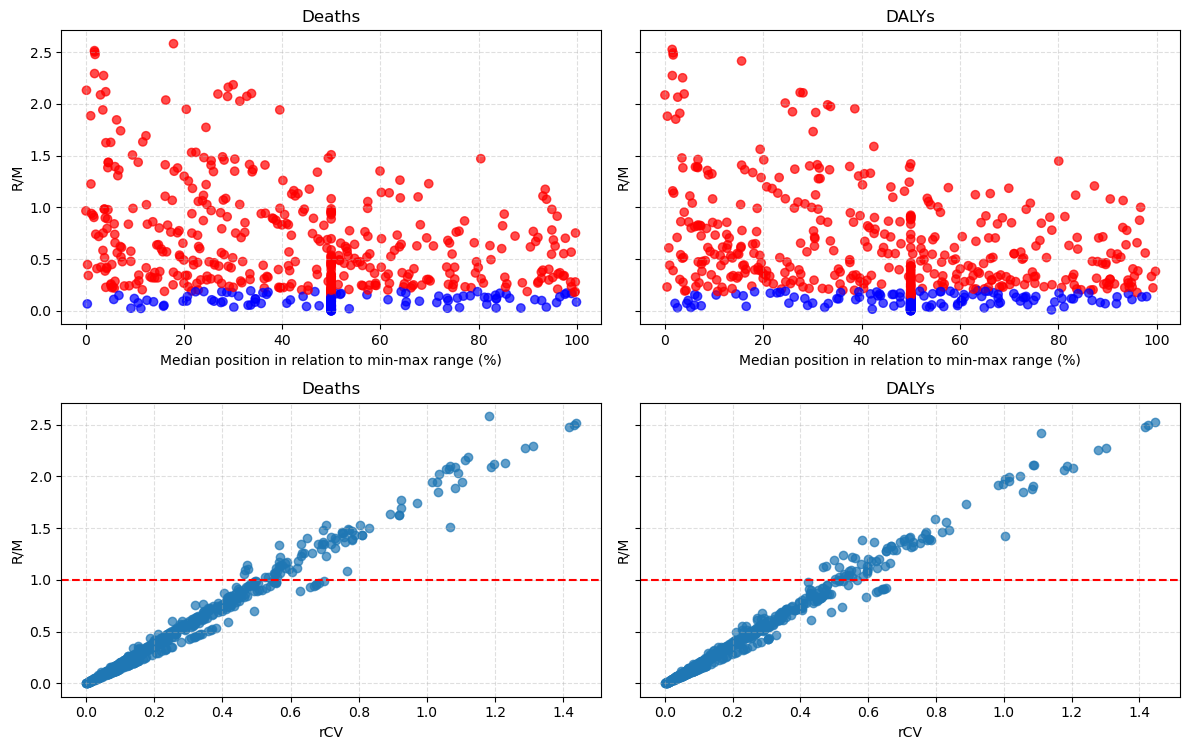

In [558]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')

# --- (0,0): Deaths (colored by rCV < 0.1) ---
mask_death = df['cv_Deaths'] < 0.1
axes[0, 0].scatter(
    df['median_position_pct_Deaths'],
    df['rmu_Deaths'],
    c=mask_death.map({True: 'blue', False: 'red'}),
    alpha=0.7
)
axes[0, 0].set_title('Deaths')
axes[0, 0].set_xlabel('Median position in relation to min-max range (%)')
axes[0, 0].set_ylabel('R/M')
axes[0, 0].grid(True, linestyle='--', alpha=0.4)

# --- (0,1): DALYs (colored by rCV < 0.1) ---
mask_daly = df['cv_DALYs'] < 0.1
axes[0, 1].scatter(
    df['median_position_pct_DALYs'],
    df['rmu_DALYs'],
    c=mask_daly.map({True: 'blue', False: 'red'}),
    alpha=0.7
)
axes[0, 1].set_title('DALYs')
axes[0, 1].set_ylabel('R/M')
axes[0, 1].set_xlabel('Median position in relation to min-max range (%)')
axes[0, 1].grid(True, linestyle='--', alpha=0.4)

# --- (1,0): Deaths (fold range vs rCV) ---
axes[1, 0].scatter(df['cv_Deaths'], df['rmu_Deaths'], alpha=0.7)
axes[1, 0].axhline(y=1, color='r', linestyle='--')
axes[1, 0].set_title('Deaths')
axes[1, 0].set_xlabel('rCV')
axes[1, 0].set_ylabel('R/M')
axes[1, 0].grid(True, linestyle='--', alpha=0.4)

# --- (1,1): DALYs (fold range vs rCV) ---
axes[1, 1].scatter(df['cv_DALYs'], df['rmu_DALYs'], alpha=0.7)
axes[1, 1].axhline(y=1, color='r', linestyle='--')
axes[1, 1].set_title('DALYs')
axes[1, 1].set_xlabel('rCV')
axes[1, 1].set_ylabel('R/M')
axes[1, 1].grid(True, linestyle='--', alpha=0.4)

# --- Layout ---
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


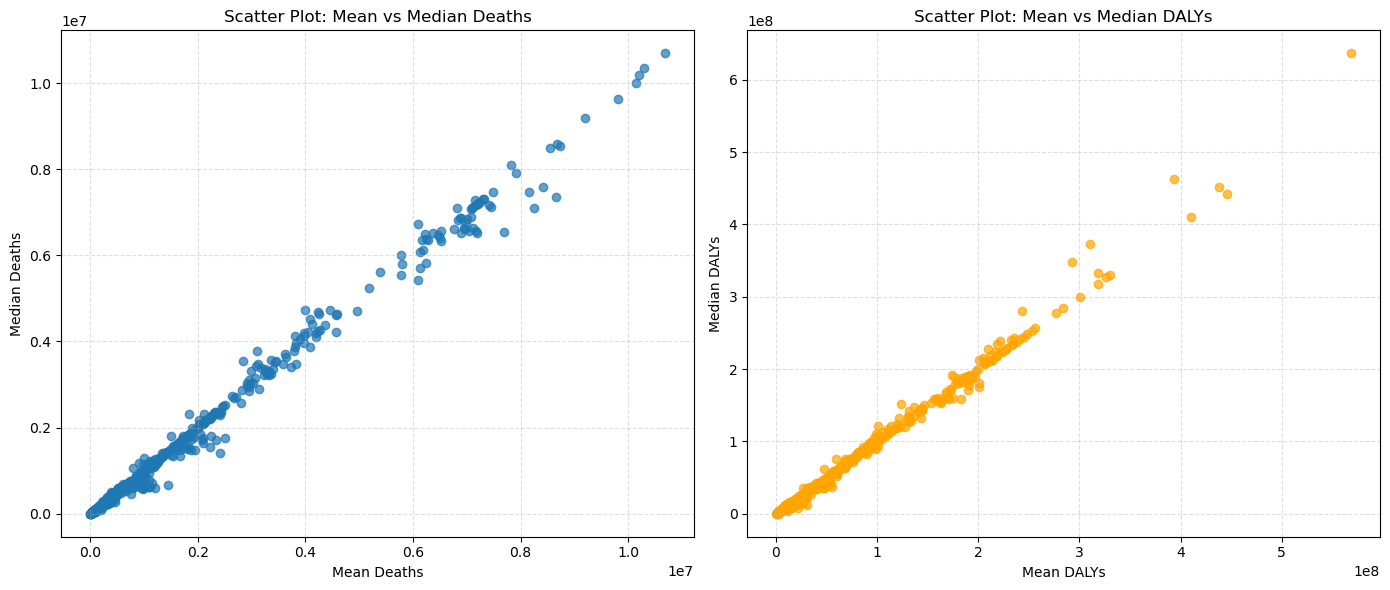

In [559]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot for Deaths
axes[0].scatter(df['mean_Deaths'], df['median_Deaths'], alpha=0.7)
axes[0].set_xlabel('Mean Deaths')
axes[0].set_ylabel('Median Deaths')
axes[0].set_title('Scatter Plot: Mean vs Median Deaths')
axes[0].grid(True, linestyle='--', alpha=0.4)

# Scatter plot for DALYs
axes[1].scatter(df['mean_DALYs'], df['median_DALYs'], alpha=0.7, color='orange')
axes[1].set_xlabel('Mean DALYs')
axes[1].set_ylabel('Median DALYs')
axes[1].set_title('Scatter Plot: Mean vs Median DALYs')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

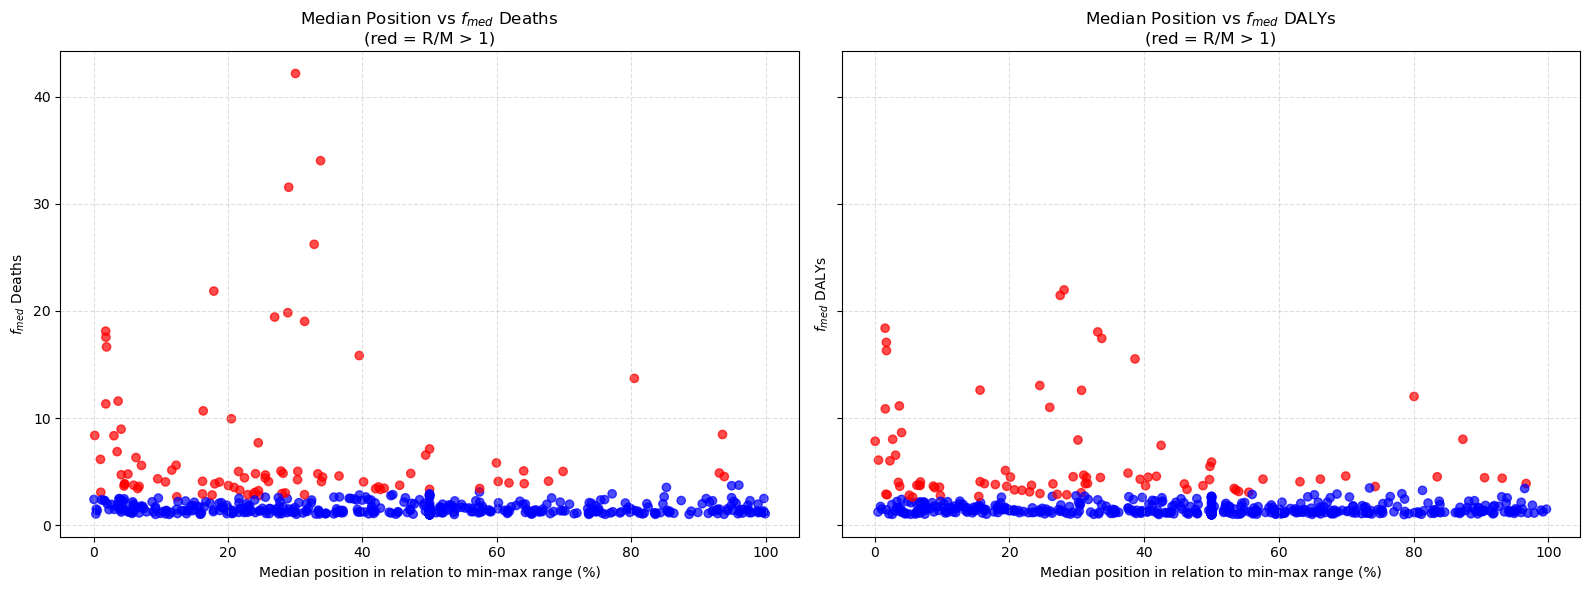

In [560]:
import matplotlib.pyplot as plt

# Create masks for the conditions
color_mask_deaths = df['rmu_Deaths'] > 1
color_mask_dalys = df['rmu_DALYs'] > 1

# Create the subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# --- Plot for Deaths ---
axes[0].scatter(
    df['median_position_pct_Deaths'],
    df['max_vs_min_Deaths'],
    c=color_mask_deaths.map({True: 'red', False: 'blue'}),
    alpha=0.7
)
axes[0].set_xlabel('Median position in relation to min-max range (%)')
axes[0].set_ylabel('$f_{med}$ Deaths')
axes[0].set_title('Median Position vs $f_{med}$ Deaths\n(red = R/M > 1)')
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- Plot for DALYs ---
axes[1].scatter(
    df['median_position_pct_DALYs'],
    df['max_vs_min_DALYs'],
    c=color_mask_dalys.map({True: 'red', False: 'blue'}),
    alpha=0.7
)
axes[1].set_xlabel('Median position in relation to min-max range (%)')
axes[1].set_ylabel('$f_{med}$ DALYs')
axes[1].set_title('Median Position vs $f_{med}$ DALYs\n(red = R/M > 1)')
axes[1].grid(True, linestyle='--', alpha=0.4)

# Adjust layout
plt.tight_layout()
plt.show()


In [561]:
# Filter the data
risk_factors_with_range_gt_1 = df[df['rmu_Deaths'] > 1]['Risk_factor']
risk_factors_with_rcv_lt_0_1_and_range_gt_1 = df[(df['cv_Deaths'] < 0.1) & (df['rmu_Deaths'] > 1)]['Risk_factor']

# Create a crosstab
crosstab = pd.crosstab(
    index=risk_factors_with_range_gt_1,
    columns=risk_factors_with_rcv_lt_0_1_and_range_gt_1,
    normalize='index'
)

# Display the crosstab
print(crosstab)

Empty DataFrame
Columns: []
Index: []


In [562]:
import pandas as pd

# Example column names — adjust if yours differ
# Risk_factor : risk factor name (string)
# R_M : your R/M ratio
# rCV : your robust coefficient of variation

# Step 1: create a mask for R/M > 1
mask_rm = df["rmu_Deaths"] > 1

# Step 2: within those, count how many also have rCV < 0.1 per risk factor
n = df[mask_rm].groupby("Risk_factor")["cv_Deaths"].apply(lambda x: (x < 0.1).sum())

# Step 3: total number of R/M > 1 per risk factor
N = df[mask_rm].groupby("Risk_factor")["cv_Deaths"].size()

# Step 4: combine into one DataFrame and make n/N string column
df_ratio = pd.DataFrame({"n": n, "N": N})
df_ratio["n_over_N"] = df_ratio["n"].astype(str) + "/" + df_ratio["N"].astype(str)

# Step 5 (optional): merge back into original df if desired
df = df.merge(df_ratio[["n_over_N"]], on="Risk_factor", how="left")

df_ratio


,n,N,n_over_N
Risk_factor,,,
Diet high in \nsugar sweetened beverages,0,10,0/10
Diet high in processed meat,0,2,0/2
Diet high in red meat,0,9,0/9
Diet high in trans fatty acids,0,9,0/9
Diet low in fruits,0,5,0/5
Diet low in legumes,0,2,0/2
Diet low in nuts and seeds,0,8,0/8
Diet low in seafood omega-3 fatty acids,0,9,0/9
Diet low in vegetables,0,8,0/8


In [563]:
import pandas as pd

# Example column names — adjust if yours differ
# Risk_factor : risk factor name (string)
# R_M : your R/M ratio
# rCV : your robust coefficient of variation

# Step 1: create a mask for R/M > 1
mask_rm = df["rmu_DALYs"] > 1

# Step 2: within those, count how many also have rCV < 0.1 per risk factor
n = df[mask_rm].groupby("Risk_factor")["cv_DALYs"].apply(lambda x: (x < 0.1).sum())

# Step 3: total number of R/M > 1 per risk factor
N = df[mask_rm].groupby("Risk_factor")["cv_DALYs"].size()

# Step 4: combine into one DataFrame and make n/N string column
df_ratio = pd.DataFrame({"n": n, "N": N})
df_ratio["n_over_N"] = df_ratio["n"].astype(str) + "/" + df_ratio["N"].astype(str)

# Step 5 (optional): merge back into original df if desired
df = df.merge(df_ratio[["n_over_N"]], on="Risk_factor", how="left")

df_ratio


,n,N,n_over_N
Risk_factor,,,
Diet high in \nsugar sweetened beverages,0,6,0/6
Diet high in processed meat,0,2,0/2
Diet high in red meat,0,9,0/9
Diet high in trans fatty acids,0,9,0/9
Diet low in fruits,0,3,0/3
Diet low in legumes,0,1,0/1
Diet low in nuts and seeds,0,8,0/8
Diet low in seafood omega-3 fatty acids,0,9,0/9
Diet low in vegetables,0,7,0/7


In [564]:
df[df['rmu_Deaths']>1]['Risk_factor'],df[(df['cv_Deaths']<0.1)&(df['rmu_Deaths']>1)]['Risk_factor']

(24               Iron deficiency
 28               Iron deficiency
 29               Iron deficiency
 57          Vitamin A deficiency
 62          Vitamin A deficiency
                  ...            
 456                Lead exposure
 466    Other environmental risks
 500            Unsafe sanitation
 506          Unsafe water source
 510          Unsafe water source
 Name: Risk_factor, Length: 90, dtype: object,
 Series([], Name: Risk_factor, dtype: object))

In [565]:
print(len(df[(df['cv_Deaths']>0.3) & (df['rmu_Deaths']>1)])/len(df[df['cv_Deaths']>0.3]))
print(len(df[(df['cv_Deaths']<0.1) & (df['rmu_Deaths']>1)])/len(df[df['rmu_Deaths']>1]))
print(df[(df['cv_Deaths']<0.1) & (df['rmu_Deaths']>1)][['min_Deaths','median_Deaths','max_Deaths','cv_Deaths','Overarching_group','Group','Risk_factor','rmu_Deaths']])

0.4090909090909091
0.0
Empty DataFrame
Columns: [min_Deaths, median_Deaths, max_Deaths, cv_Deaths, Overarching_group, Group, Risk_factor, rmu_Deaths]
Index: []


In [566]:
# Crosstab for DALYs
dalys_crosstab = pd.crosstab(
    index=df['Overarching_group'],
    columns=(df['rmu_DALYs'] > 1) & (df['cv_DALYs'] < 0.1)
)
print("Crosstab for DALYs with Overarching Group:")
print(dalys_crosstab)

dalys_crosstab_group = pd.crosstab(
    index=df['Group'],
    columns=(df['rmu_DALYs'] > 1) & (df['cv_DALYs'] < 0.1)
)
print("\nCrosstab for DALYs with Group:")
print(dalys_crosstab_group)

# Crosstab for Deaths
deaths_crosstab = pd.crosstab(
    index=df['Overarching_group'],
    columns=(df['rmu_Deaths'] > 1) & (df['cv_Deaths'] < 0.1)
)
print("\nCrosstab for Deaths with Overarching Group:")
print(deaths_crosstab)

deaths_crosstab_group = pd.crosstab(
    index=df['Group'] ,
    columns=(df['rmu_Deaths'] > 1) & (df['cv_Deaths'] < 0.1)
)
print("\nCrosstab for Deaths with Group:")
print(deaths_crosstab_group)

Crosstab for DALYs with Overarching Group:
col_0                             False
Overarching_group                      
Behavioural risks                   324
Environmental/occupational risks    220
Metabolic risks                      60

Crosstab for DALYs with Group:
col_0                                      False
Group                                           
Air pollution                                 50
Child and maternal malnutrition               74
Dietary risks                                160
Drug use                                      10
High LDL cholesterol*                         10
High alcohol use                              10
High body-mass index                          10
High fasting plasma glucose                   10
High systolic blood pressure                  10
Intimate partner violence                     10
Kidney dysfunction*                           10
Low bone mineral density                      10
Low physical activity                  

In [567]:
df.columns

Index(['Overarching_group', 'Group', 'Risk_factor', 'anal_year',
       'median_Deaths', 'min_Deaths', 'max_Deaths', 'n_estimates_Deaths',
       'mean_Deaths', 'std_Deaths', 'mad_Deaths', 'range_Deaths',
       'fold_range_vs_median_Deaths', 'rmu_Deaths', 'cv_Deaths',
       'max_vs_min_Deaths', 'f_med_Deaths', 'rcv_m_Deaths', 'median_DALYs',
       'min_DALYs', 'max_DALYs', 'n_estimates_DALYs', 'mean_DALYs',
       'std_DALYs', 'mad_DALYs', 'range_DALYs', 'fold_range_vs_median_DALYs',
       'rmu_DALYs', 'cv_DALYs', 'max_vs_min_DALYs', 'f_med_DALYs',
       'rcv_m_DALYs', 'median_position_pct_DALYs',
       'median_position_pct_Deaths', 'median_bin_DALYs', 'median_bin_Deaths',
       'n_over_N_x', 'n_over_N_y'],
      dtype='object')

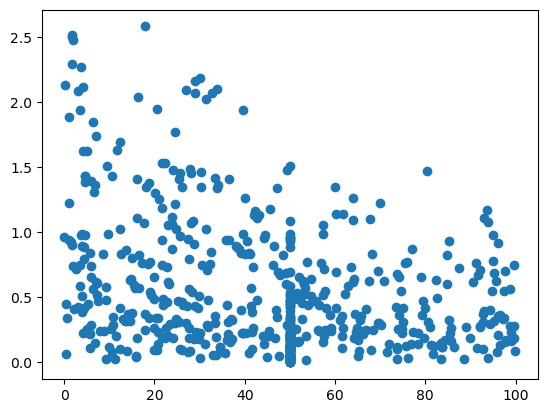

In [568]:
plt.scatter((df['median_position_pct_Deaths']),(df['rmu_Deaths']))#.to_csv('./listenmaniheardsheevengot a diamond piece man.csv')

In [569]:
df_filtered = df[
    (df['cv_DALYs'] > 0.3) &
    (df['rmu_DALYs'] < 1)]

df_filtered[['Risk_factor','anal_year','min_DALYs','median_DALYs','max_DALYs','rmu_DALYs','cv_DALYs']]

,Risk_factor,anal_year,min_DALYs,median_DALYs,max_DALYs,rmu_DALYs,cv_DALYs
1,Child and maternal malnutrition,2005,2.483390e+08,4.629601e+08,4.681612e+08,0.559126,0.319061
5,Child and maternal malnutrition,2013,1.768590e+08,3.726985e+08,3.809262e+08,0.657939,0.372440
6,Child and maternal malnutrition,2015,1.721200e+08,3.473889e+08,3.591062e+08,0.638458,0.357624
25,Iron deficiency,2005,3.066649e+07,3.444998e+07,5.512000e+07,0.610135,0.328420
44,Suboptimal breastfeeding,1990,4.713556e+07,7.881483e+07,1.168010e+08,0.866577,0.477156
...,...,...,...,...,...,...,...
496,Unsafe sanitation,1990,3.605000e+07,1.209526e+08,1.240490e+08,0.875603,0.427844
530,High LDL cholesterol*,2010,4.090000e+07,7.624937e+07,8.726238e+07,0.680426,0.355494
576,Low bone mineral density,1990,3.125000e+06,8.838317e+06,1.090300e+07,0.981308,0.422862
580,Low bone mineral density,2010,5.216000e+06,1.332888e+07,1.393241e+07,0.805154,0.449628


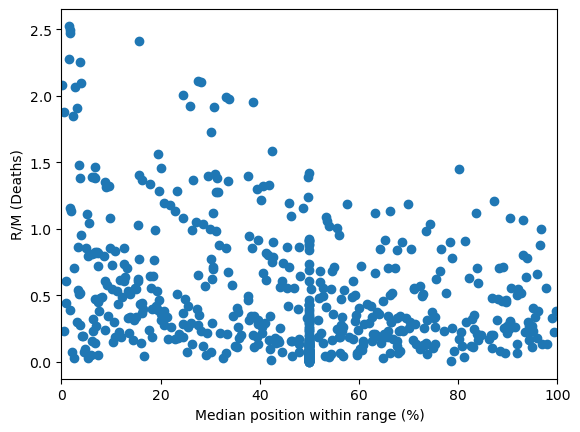

In [570]:
plt.scatter((df['median_position_pct_DALYs']),(df['rmu_DALYs']))#.to_csv('./listenmaniheardsheevengot a diamond piece man.csv')
plt.xlabel('Median position within range (%)')
plt.ylabel('R/M (Deaths)')
plt.xlim(0,100)
plt.grid(False)

In [571]:
pivoted = format_and_pivot_summary(summary_wide_cons, value_cols=('DALYs','Deaths'))

# Access the pivoted DALYs table
summary_wide_cons_wide = pivoted['Deaths']
summary_wide_cons_wide.to_csv('./data/processed_data/Rawdata for Heatmap.csv')
summary_wide_cons_wide

anal_year,1990,2005,2006,2007,2010,2013,2015,2016,2017,2019
Risk_factor,,,,,,,,,,
Air pollution,6501 (4808-7341) [0.4],6557 (6466-8099) [0.2],6529 (6220-7954) [0.3],6528 (4630-7943) [0.5],7299 (6576-8022) [0.2],6620 (5527-8157) [0.4],6638 (6485-8210) [0.2],6605 (6116-8203) [0.3],6564 (4900-8123) [0.5],7319 (6672-7966) [0.2]
Ambient ozone pollution,175 (133-235) [0.6],302 (207-359) [0.5],317 (188-371) [0.6],391 (330-392) [0.2],314 (152-390) [0.8],310 (217-393) [0.6],321 (254-410) [0.5],342 (234-438) [0.6],459 (356-472) [0.3],418 (365-470) [0.3]
Ambient particulate matter pollution,2336 (2047-2910) [0.4],3255 (2913-3934) [0.3],3242 (2951-3687) [0.2],3033 (2420-3302) [0.3],3359 (3224-3617) [0.1],3699 (2926-4240) [0.4],4241 (3871-4583) [0.2],4093 (3876-4630) [0.2],3882 (2940-4612) [0.4],4372 (4141-4602) [0.1]
Chewing tobacco,25 (25-25) [0.0],37 (37-37) [0.0],38 (38-38) [0.0],39 (39-59) [0.4],41 (41-41) [0.0],45 (44-45) [0.0],48 (47-48) [0.0],49 (49-50) [0.0],52 (51-76) [0.4],55 (54-56) [0.0]
Child and maternal malnutrition,6738 (4254-7264) [0.5],4730 (2280-4954) [0.7],4605 (4301-4795) [0.1],4640 (4486-4650) [0.0],4200 (4165-4235) [0.0],3788 (1665-3838) [0.7],3539 (1414-3545) [0.8],3377 (2737-3402) [0.2],3225 (3190-3256) [0.0],2944 (2938-2951) [0.0]
...,...,...,...,...,...,...,...,...,...,...
Unsafe sex,453 (430-679) [0.5],1661 (1517-2051) [0.3],1615 (1469-1800) [0.2],1539 (1400-1750) [0.2],1265 (1216-1313) [0.1],1146 (1060-1481) [0.3],1089 (1010-1452) [0.4],1073 (995-1101) [0.1],1030 (977-1042) [0.1],964 (944-984) [0.0]
Unsafe water source,2304 (288-2442) [1.2],1587 (1485-1768) [0.2],1571 (1463-1752) [0.2],1500 (1436-1723) [0.2],1304 (116-1592) [1.5],1246 (1157-1462) [0.2],1251 (1044-1363) [0.3],1160 (997-1328) [0.3],1230 (960-1319) [0.3],1055 (879-1230) [0.3]
"Unsafe water, sanitation, and handwashing",3151 (2727-3222) [0.2],2197 (2179-2352) [0.1],2231 (2163-2329) [0.1],2123 (1990-2289) [0.1],2026 (1935-2118) [0.1],1740 (1399-1957) [0.3],1766 (1589-1835) [0.1],1661 (1524-1788) [0.2],1610 (1470-1770) [0.2],1505 (1354-1657) [0.2]


In [572]:
temporary=summary_wide_cons[(summary_wide_cons['rmu_Deaths']>1.5)&(summary_wide_cons['rmu_Deaths']<5)]
temporary['Risk_factor']+' '+temporary['anal_year'].astype(str)

29                              Iron deficiency 2013
57                         Vitamin A deficiency 2007
62                         Vitamin A deficiency 2017
64                              Zinc deficiency 1990
65                              Zinc deficiency 2005
66                              Zinc deficiency 2006
67                              Zinc deficiency 2007
68                              Zinc deficiency 2010
69                              Zinc deficiency 2013
70                              Zinc deficiency 2015
71                              Zinc deficiency 2016
72                              Zinc deficiency 2017
75     Diet high in \nsugar sweetened beverages 2005
76     Diet high in \nsugar sweetened beverages 2006
80     Diet high in \nsugar sweetened beverages 2015
81     Diet high in \nsugar sweetened beverages 2016
94                        Diet high in red meat 1990
95                        Diet high in red meat 2005
96                        Diet high in red mea

In [ ]:
# Using your wide summary
sorted_df = compute_proportions(summary_wide_cons, output_csv='./tables/eTable 3.csv')
sorted_df

,Overarching_group,Group,DALYs,Deaths
0,Behavioural risks,NaN,66/324 (0.2),79/324 (0.24)
0,Behavioural risks,Child and maternal malnutrition,11/74 (0.15),13/74 (0.18)
1,Behavioural risks,Dietary risks,51/160 (0.32),60/160 (0.38)
2,Behavioural risks,Drug use,0/10 (0.0),1/10 (0.1)
3,Behavioural risks,High alcohol use,0/10 (0.0),0/10 (0.0)
4,Behavioural risks,Intimate partner violence,0/10 (0.0),0/10 (0.0)
5,Behavioural risks,Low physical activity,4/10 (0.4),5/10 (0.5)
6,Behavioural risks,Tobacco,0/40 (0.0),0/40 (0.0)
7,Behavioural risks,Unsafe sex,0/10 (0.0),0/10 (0.0)
1,Environmental/occupational risks,NaN,11/220 (0.05),8/220 (0.04)


In [574]:
# Calculate the percentage of rows with cv_Deaths > 0.2 by Group
percentage_cv_deaths_by_group = df.groupby('Group')['cv_Deaths'].apply(lambda x: (x > 0.2).mean() * 100)

# Calculate the percentage of rows with cv_DALYs > 0.2 by Group
percentage_cv_dalys_by_group = df.groupby('Group')['cv_DALYs'].apply(lambda x: (x > 0.2).mean() * 100)

# Print the results
print("Percentage of rows with cv_Deaths > 0.2 by Group:")
print(percentage_cv_deaths_by_group)

print("\nPercentage of rows with cv_DALYs > 0.2 by Group:")
print(percentage_cv_dalys_by_group)

Percentage of rows with cv_Deaths > 0.2 by Group:
Group
Air pollution                                36.000000
Child and maternal malnutrition              47.297297
Dietary risks                                85.000000
Drug use                                     20.000000
High LDL cholesterol*                        10.000000
High alcohol use                             70.000000
High body-mass index                         60.000000
High fasting plasma glucose                  10.000000
High systolic blood pressure                  0.000000
Intimate partner violence                    90.000000
Kidney dysfunction*                           0.000000
Low bone mineral density                     20.000000
Low physical activity                        90.000000
Non-optimal temperature                      30.000000
Occupational risks                           38.571429
Other environmental risks                    70.000000
Tobacco                                      12.500000
Unsafe se

In [575]:
# Calculate medians for each group, skipping NaN values
behavioural_risks_median = summary_wide_cons[summary_wide_cons['Overarching_group'] == 'Behavioural risks'].rmu_Deaths.median(skipna=True)
environmental_risks_median = summary_wide_cons[summary_wide_cons['Overarching_group'] == 'Environmental/occupational risks'].rmu_Deaths.median(skipna=True)
metabolic_risks_median = summary_wide_cons[summary_wide_cons['Overarching_group'] == 'Metabolic risks'].rmu_Deaths.median(skipna=True)

# Print the results
print(f"Behavioural risks median R/M: {behavioural_risks_median}")
print(f"Environmental/occupational risks median R/M: {environmental_risks_median}")
print(f"Metabolic risks median R/M: {metabolic_risks_median}")

# Calculate medians for each group, skipping NaN values
behavioural_risks_median = summary_wide_cons[summary_wide_cons['Overarching_group'] == 'Behavioural risks'].rmu_DALYs.median(skipna=True)
environmental_risks_median = summary_wide_cons[summary_wide_cons['Overarching_group'] == 'Environmental/occupational risks'].rmu_DALYs.median(skipna=True)
metabolic_risks_median = summary_wide_cons[summary_wide_cons['Overarching_group'] == 'Metabolic risks'].rmu_DALYs.median(skipna=True)

# Print the results
print(f"Behavioural risks median R/M: {behavioural_risks_median}")
print(f"Environmental/occupational risks median R/M: {environmental_risks_median}")
print(f"Metabolic risks median R/M: {metabolic_risks_median}")

print('Median range/mean deaths risks 1990-2021: '+str(summary_wide_cons.rmu_Deaths.median())+' ('+str(summary_wide_cons.rmu_Deaths.min())+'-'+str(summary_wide_cons.rmu_Deaths.max())+')',
    '\nMedian range/mean daly risks 1990-2021: '+str(summary_wide_cons.rmu_DALYs.median())+' ('+str(summary_wide_cons.rmu_DALYs.min())+'-'+str(summary_wide_cons.rmu_DALYs.max())+')' + '')

Behavioural risks median R/M: 0.6
Environmental/occupational risks median R/M: 0.3
Metabolic risks median R/M: 0.25
Behavioural risks median R/M: 0.5
Environmental/occupational risks median R/M: 0.2
Metabolic risks median R/M: 0.25
Median range/mean deaths risks 1990-2021: 0.4 (0.0-2.6) 
Median range/mean daly risks 1990-2021: 0.3 (0.0-2.5)


In [576]:
summary_wide_cons['rmu_Deaths'].quantile(0.25), summary_wide_cons['rmu_Deaths'].quantile(0.75)

(0.2, 0.8)

In [577]:
summary_wide_cons['rmu_DALYs'].quantile(0.25), summary_wide_cons['rmu_DALYs'].quantile(0.75)

(0.1, 0.7)

In [578]:
# Calculate the percentage of rows with cv_Deaths > 0.2
percentage_cv_deaths = (df['cv_Deaths'] > 0.5).mean() * 100

# Calculate the percentage of rows with cv_DALYs > 0.2
percentage_cv_dalys = (df['cv_DALYs'] > 0.5).mean() * 100

print(f"Percentage of rows with cv_Deaths > 0.2: {percentage_cv_deaths:.2f}%")
print(f"Percentage of rows with cv_DALYs > 0.2: {percentage_cv_dalys:.2f}%")

Percentage of rows with cv_Deaths > 0.2: 17.38%
Percentage of rows with cv_DALYs > 0.2: 15.56%


In [579]:
(df['cv_Deaths'] > 0.5).sum()

105

# Dietary deep dive

In [580]:
dfs=pd.read_csv('./data/total.csv')

### Unique subgroups

In [581]:
dfs.columns

Index(['Unnamed: 0', 'measure_id', 'measure_name', 'location_id',
       'location_name', 'sex_id', 'sex_name', 'age_id', 'age_name', 'cause_id',
       'cause_name', 'rei_id', 'rei_name', 'metric_id', 'metric_name', 'year',
       'val', 'upper', 'lower', 'anal_year'],
      dtype='object')

In [582]:
cols = ['rei_name', 'sex_name', 'location_name', 'cause_name', 
        'measure_name', 'age_name']

for col in cols:
    print(f"\n{col} unique values:")
    print(len(dfs[col].unique()))


rei_name unique values:
16

sex_name unique values:
3

location_name unique values:
60

cause_name unique values:
3

measure_name unique values:
4

age_name unique values:
49


In [583]:
# Filter out groups that do not have at least two unique anal_year values (baseline comparator)
# Create a mask to identify groups with more than one unique anal_year
mask = dfs.groupby(['rei_id', 'sex_id', 'year', 'cause_name','measure_name', 'age_id', 'location_id'])['anal_year'] \
    .transform('nunique') > 1

# Apply the mask to filter the DataFrame
valid_groups = dfs[mask]
valid_groups.set_index(['rei_id', 'sex_id', 'year', 'cause_name','measure_name', 'age_id', 'location_id'], inplace=True)
reference_anal_year=2021
reference_df = valid_groups[valid_groups['anal_year'] == reference_anal_year]
valid_groups=valid_groups[valid_groups['anal_year'] != reference_anal_year]

# Merge valid_groups (various years) with reference_df (2021 data) based on the index
merged_df = valid_groups[['val']].merge(
    reference_df[['val']], 
    left_index=True, 
    right_index=True, 
    suffixes=('_2019', '_2021')  # Rename columns for clarity
)

# Compute Pearson correlation using .corr()
#correlation = merged_df.corr().loc['estimate_other', 'estimate_2021']

#grouped_corr = merged_df.groupby(level=['rei_id', 'sex_id', 'year', 'cause_name', 'measure_name', 'age_id', 'location_id']).corr().unstack().loc[:, ('estimate_other', 'estimate_2021')]

# Create a multi-level pivot table where '2019' and '2021' estimates are columns
pivot_df = merged_df.pivot_table(index=['rei_id', 'sex_id', 'year', 'cause_name', 'measure_name', 'age_id', 'location_id'],
                                 values=['val_2019', 'val_2021'])

merged_df.dropna(subset=['val_2019', 'val_2021'], inplace=True)

In [584]:
merged_df = valid_groups.join(reference_df[['val', 'lower', 'upper']], rsuffix='_ref', how='inner')

In [585]:
from pandarallel import pandarallel# parallel apply
pandarallel.initialize()
merged_df['position'] = merged_df.parallel_apply(interval_position, axis=1)
merged_df['interval_overlap'] = merged_df.parallel_apply(intervals_overlap, axis=1)

# Extract the results
results_df = merged_df.reset_index()[[
    'anal_year', 'year', 'sex_id', 'sex_name', 'rei_id', 'rei_name','measure_name',
    'lower', 'upper', 'val','val_ref','lower_ref','upper_ref', 'position', 'interval_overlap'
]]

results_df=results_df[results_df['measure_name'].isin(['Deaths','DALYs (Disability-Adjusted Life Years)'])]
results_df.to_csv('./data/dietary_deep_dive.csv', index=False)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.


In [586]:
measure_names = results_df['measure_name'].unique()
for measure in measure_names:
    measure_df = results_df[results_df['measure_name'] == measure]
    breakdown = measure_df.groupby(['rei_name', 'position']).size().unstack(fill_value=0)
    total_counts = breakdown.sum(axis=1)
    percentages = (breakdown.T / total_counts).T
    percentages[percentages['within']<0.5]
    print(f"\nMeasure: {measure}")
    print(percentages[percentages['within']<0.5])
    #print(percentages)


Measure: DALYs (Disability-Adjusted Life Years)
position                                    above     below    within
rei_name                                                             
Diet high in red meat                    0.000000  0.776375  0.223625
Diet high in sugar-sweetened beverages   0.003908  0.673294  0.322799
Diet low in fruits                       0.707593  0.000000  0.292407
Diet low in polyunsaturated fatty acids  0.620173  0.000000  0.379827
Diet low in seafood omega-3 fatty acids  0.911844  0.022191  0.065965
Diet low in vegetables                   0.621720  0.000000  0.378280

Measure: Deaths
position                                    above     below    within
rei_name                                                             
Diet high in red meat                    0.000397  0.781923  0.217680
Diet high in sugar-sweetened beverages   0.000000  0.808532  0.191468
Diet low in fruits                       0.684106  0.000117  0.315777
Diet low in seafood omeg

In [587]:
measure_names = results_df['measure_name'].unique()
for measure in measure_names:
    measure_df = results_df[results_df['measure_name'] == measure]
    breakdown = measure_df.groupby(['rei_name', 'position']).size().unstack(fill_value=0)
    total_counts = breakdown.sum(axis=1)
    percentages = (breakdown.T / total_counts).T
    percentages[percentages['within']<0.5]
    breakdown['Total'] = total_counts
    print(f"\nMeasure: {measure}")
    print(breakdown)


Measure: DALYs (Disability-Adjusted Life Years)
position                                  above   below  within   Total
rei_name                                                               
Diet high in processed meat               22353   10828  223499  256680
Diet high in red meat                         0  199280   57400  256680
Diet high in sodium                         402      40  256238  256680
Diet high in sugar-sweetened beverages     1003  172821   82856  256680
Diet high in trans fatty acids                0  107702  148978  256680
Diet low in calcium                        8822  109570  138288  256680
Diet low in fiber                          1452    1746  253482  256680
Diet low in fruits                       181625       0   75055  256680
Diet low in legumes                           0     532  256148  256680
Diet low in milk                          20560   39466  196654  256680
Diet low in nuts and seeds                33810     540  222330  256680
Diet low in pol

In [588]:
results_df=pd.read_csv('./data/processed_data/dietary_deep_dive.csv')

In [ ]:
results_df.columns

Index(['anal_year', 'year', 'sex_id', 'sex_name', 'rei_id', 'rei_name',
       'measure_name', 'lower', 'upper', 'val', 'val_ref', 'lower_ref',
       'upper_ref', 'position', 'interval_overlap'],
      dtype='object')